<a href="https://colab.research.google.com/github/financieras/articulos/blob/main/english_part1_gradient_descent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Gradient Descent for Linear Regression. Part 1/2**
#### **Understanding the Algorithm and Basic Implementation**  


 <a href="https://github.com/magnitopic" target="_blank"><img src="https://img.shields.io/badge/GitHub-100000?style=flat&logo=github&logoColor=white" alt="GitHub" style="display: inline-block; vertical-align: middle; margin-right: 10px;"/></a><a href="https://www.kaggle.com/magnitopic" target="_blank"><img src="https://img.shields.io/badge/Kaggle-20BEFF?style=flat&logo=kaggle&logoColor=white" alt="Kaggle" style="display: inline-block; vertical-align: middle; margin-right: 10px;"/></a><a href="https://www.linkedin.com/in/magnitopic" target="_blank"><img src="https://img.shields.io/badge/LinkedIn-0A66C2?style=flat&logo=linkedin&logoColor=white" alt="LinkedIn" style="display: inline-block; vertical-align: middle; margin-right: 10px;"/></a>

 > **This is Part 1 of 2 in our series on Gradient Descent.**
> Here you'll learn the intuition, essential mathematics, and basic implementation of the algorithm. In Part 2, we'll cover hyperparameters, feature scaling, and professional implementations.

If you want to review the fundamentals of linear regression and the least squares method, I recommend reading my article [Linear Regression from Scratch in Python](https://www.kaggle.com/code/magnitopic/linear-regression-from-scratch-in-python-part-1-2) first, where these concepts are covered from scratch.

### The Star Algorithm of Machine Learning

Gradient Descent is the optimization engine behind virtually all modern Machine Learning. In this article, you'll learn how this algorithm works by applying it to Linear Regression, combining accessible theory with practical code so you understand **why it works** and **how to implement it** step by step.

By the end of this article, you'll have built your own Gradient Descent algorithm from scratch and will understand the foundation upon which neural networks are built.

## **1. Introduction: What Problem Are We Trying to Solve?**

At the heart of Machine Learning lies a fundamental task: **prediction**. We want to use data we already have to make intelligent estimates about data we haven't seen yet.

Let's take a classic and practical example: **predicting the price of a house based on its size**.

### The Prediction Problem

Imagine you have a dataset of houses. For each one, you know its **size in square meters** (our input variable $x$) and the **sale price** (our target variable $y$). If we plot this data on a scatter plot, we'll see a cloud of points with a clear trend: the larger the area, the higher the price (although with some dispersion).

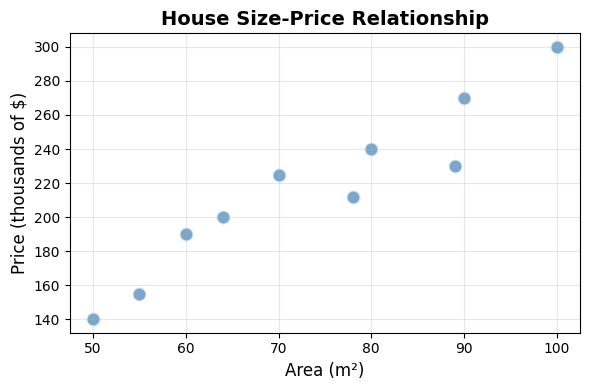

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Sample data: house size vs price
area = np.array([50, 55, 60, 64, 70, 78, 80, 89, 90, 100])
price = np.array([140000, 155000, 190000, 200000, 225000,
                  212000, 240000, 230000, 270000, 300000])

plt.figure(figsize=(6, 4))
plt.scatter(area, price/1000, alpha=0.7, s=100, color='steelblue', edgecolors='white', linewidth=1.5)
plt.xlabel('Area (m²)', fontsize=12)
plt.ylabel('Price (thousands of $)', fontsize=12)
plt.title('House Size-Price Relationship', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Our goal is to find **a straight line** that best captures this trend. This line will be our **Linear Regression** model.

Why is this interesting? Because once the model is trained, if we're given the area of a new house ($x$), we can use the line to **estimate** its likely price ($\hat{y}$).

### The Model Equation

The equation of a straight line is well known:

$$\hat{y} = w_0 + w_1 x$$

Where:
- $x$: house area is our input variable (the *feature*).
- $\hat{y}$: estimated price is our model's prediction. We distinguish it from the actual $y$ (the true sale price).
- $w_0$: **intercept** or bias. Value of $\hat{y}$ when $x = 0$.
- $w_1$: **slope** or weight. How much the price increases for each additional square meter.

**Objective:** Find the parameters $ w_0 $ and $ w_1 $ that give us the line that best fits the cloud of points.

There are two main approaches:

1. **Closed-form Solution (Normal Equation)**  
   A direct analytical formula:  
   $$\mathbf{w} = (\mathbf{X}^T \mathbf{X})^{-1} \mathbf{X}^T \mathbf{y}$$  
   It's exact and fast for small datasets, but becomes very expensive (and sometimes impossible) with millions of data points or thousands of variables.

2. **Gradient Descent**  
   An iterative algorithm that "walks" toward optimal values by progressively adjusting the parameters.  
   **Key advantages:**
   - Scales to enormous datasets and thousands of features
   - Works with data that doesn't fit in memory (batch processing)
   - Is the foundation of virtually all Deep Learning
   - Allows continuous model updating (online learning)
   - Works for non-linear problems and neural networks

In real-world problems (hundreds of thousands or millions of observations), the closed-form solution simply isn't viable. That's why we need to understand and master **Gradient Descent**.

### What Will You Learn in This Part 1?

- The intuition behind the algorithm.
- How to measure a line's error: the **cost function**.
- The essential mathematics: what the gradient is and why "descending" leads us to the minimum.
- Implement Gradient Descent from scratch with NumPy.
- Visualize the optimization process and understand what happens internally at each step.

In **Part 2** we'll dive deeper into:
- critical hyperparameters (learning rate)
- feature scaling
- algorithm variants (Batch, Mini-Batch, SGD)
- comparison with professional implementations like scikit-learn.

But before implementing anything, we need to answer a fundamental question: how do we measure how "good" or "bad" a line is? For that, we'll introduce the Cost Function.

# **2. Measuring Error: The Cost Function**

To find the "best" line, we need an objective way to measure how well a line fits the data.

## **The Residual: Error at a Point**

For each house $i$, we know its actual area $x_i$ and its actual price $y_i$. Our line predicts a price $\hat{y}_i = w_0 + w_1 x_i$.

The vertical difference between the actual point and the prediction is called the **residual**:

$$e_i = y_i - \hat{y}_i$$

- If $e_i > 0$, the point is above the line (we underestimated the price).
- If $e_i < 0$, the point is below (we overestimated).